In [5]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

In [6]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [7]:
#importing dataset
ds = pd.read_csv('/content/drive/MyDrive/Minor Project/netflix_titles.csv')
ds.head(5)
ds_copy = ds.copy()

In [8]:
#checking total number of null values in each column
ds.isnull().sum()

,0
show_id,0
type,0
title,0
director,2634
cast,825
country,831
date_added,10
release_year,0
rating,4
duration,3


In [9]:
#dropping null values in required columns
ds_copy.dropna(subset=['type', 'date_added', 'release_year'], inplace=True)

In [10]:
#extract month and day added
ds_copy['date_added'] = ds_copy['date_added'].str.strip()
ds_copy['date_added'] = pd.to_datetime(ds_copy['date_added'])
ds_copy['year_added'] = ds_copy['date_added'].dt.year
ds_copy['month_added'] = ds_copy['date_added'].dt.month

In [11]:
#splitting 'listed in' into different genres
ds_copy['genre'] = ds_copy['listed_in'].str.split(', ')
ds_copy = ds_copy.explode('genre')

In [12]:
#Grouping data according to release_year and type
type_year = ds_copy.groupby(['release_year', 'type']).size().reset_index(name='count')
#Grouping data according to genre and type
genre_type = ds_copy.groupby(['genre', 'type']).size().reset_index(name='count')
#Grouping data according to genre and release year
genre_year = ds_copy.groupby(['release_year','genre']).size().reset_index(name='count')
#grouping data according to year added and type
year_added_type = ds_copy.groupby(['year_added', 'type']).size().reset_index(name='count')

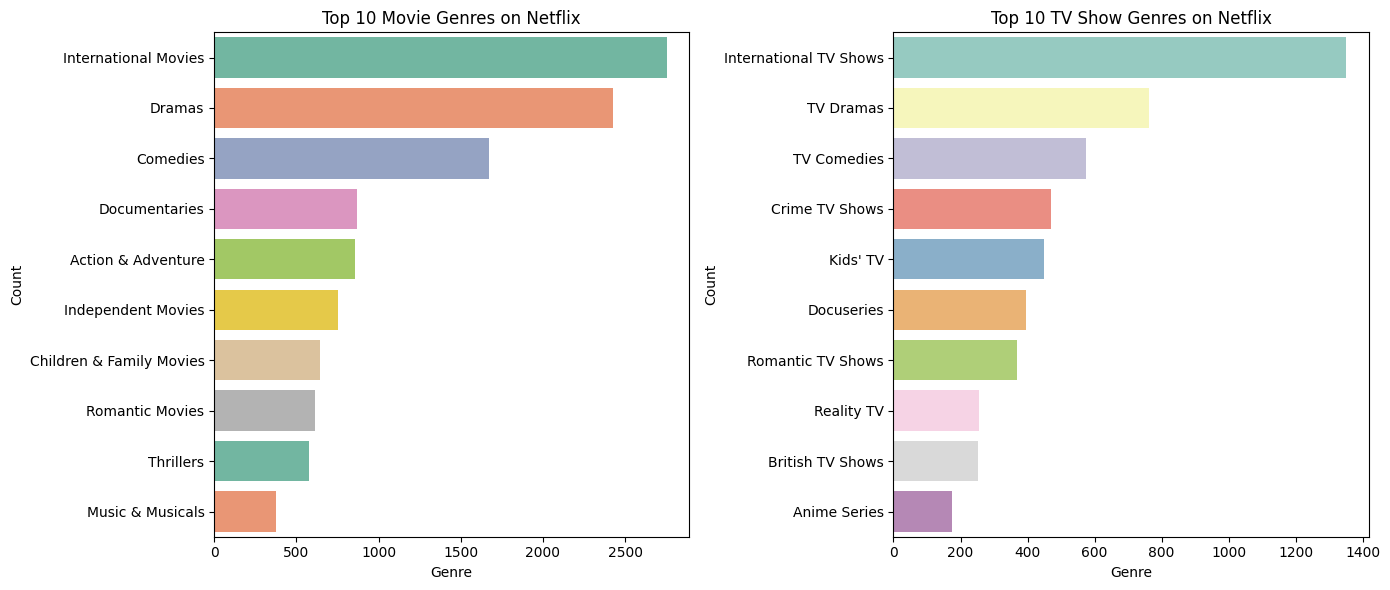

In [13]:
#Extracting Top genres for bith TV Shows and Movies
genre_movie = genre_type[genre_type['type']=='Movie']
genre_tvshow = genre_type[genre_type['type']=='TV Show']
top_10_movie_genres = genre_movie.sort_values(by='count', ascending=False).head(10)
top_10_movie_tvshow = genre_tvshow.sort_values(by='count', ascending=False).head(10)

plt.figure(figsize=(14, 6))

#Top 10 Movie Genres
plt.subplot(1, 2, 1)
sns.barplot(x='count', y='genre', data=top_10_movie_genres, palette='Set2')
plt.title('Top 10 Movie Genres on Netflix')
plt.xlabel('Genre')
plt.ylabel('Count')

#Top 10 TV Show Genres
plt.subplot(1, 2, 2)
sns.barplot(x='count', y='genre', data=top_10_movie_tvshow, palette='Set3')
plt.title('Top 10 TV Show Genres on Netflix')
plt.xlabel('Genre')
plt.ylabel('Count')

plt.tight_layout()
plt.show()

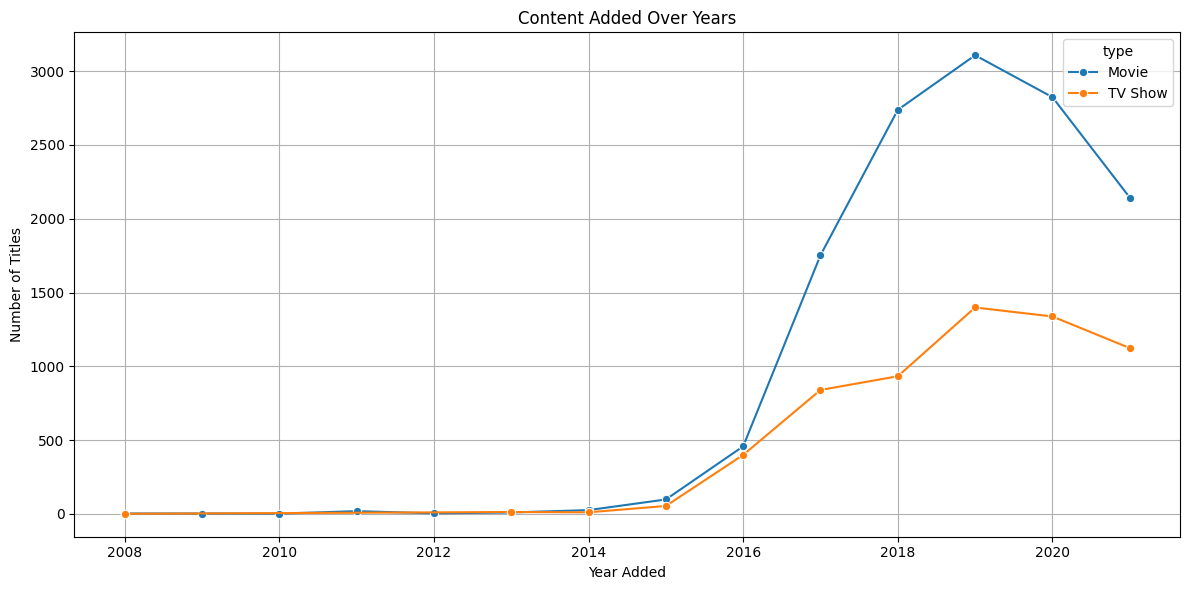

In [14]:
#Line plotting to visualize content addition over years
plt.figure(figsize=(12, 6))
sns.lineplot(data=year_added_type, x='year_added', y='count', hue='type', marker='o')
plt.title("Content Added Over Years")
plt.xlabel("Year Added")
plt.ylabel("Number of Titles")
plt.grid(True)
plt.tight_layout()
plt.show()

In [15]:
#Extracting Movies and TV shows from dataset
ds_movies = ds[ds['type'] == 'Movie']
ds_tvshow = ds[ds['type'] == 'TV Show']

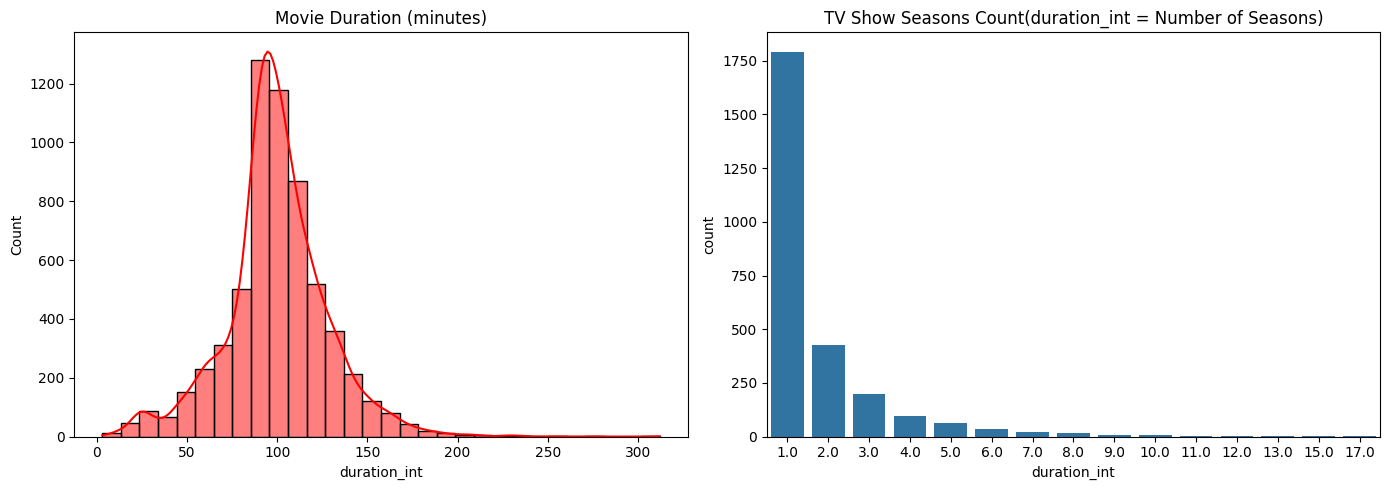

In [16]:
#Duration distributuion for movies and season distribution for TV shows
# Convert 'duration' for movies
ds_movies['duration_int'] = ds_movies['duration'].str.extract(r'(\d+)').astype(float)
# Convert 'duration' for TV shows
ds_tvshow['duration_int'] = ds_tvshow['duration'].str.extract(r'(\d+)').astype(float)

plt.figure(figsize=(14, 5))

#Histogram for Movie durations
plt.subplot(1, 2, 1)
sns.histplot(ds_movies['duration_int'], bins=30, color='red',kde=True)
plt.title('Movie Duration (minutes)')

#Countplot for TV show seasons
plt.subplot(1, 2, 2)
sns.countplot(x='duration_int', data=ds_tvshow, order=ds_tvshow['duration_int'].unique().sort())
plt.title('TV Show Seasons Count(duration_int = Number of Seasons)')
plt.tight_layout()
plt.show()

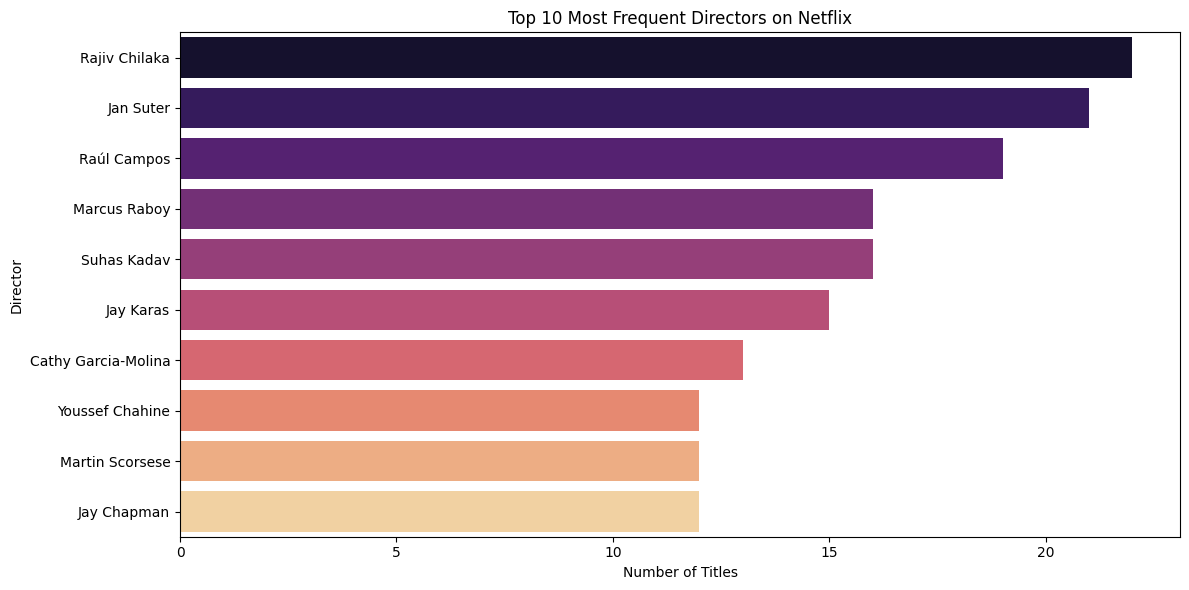

In [17]:
#cleaning null values in directors
ds_copy_2 = ds.copy()
ds_copy_2.dropna(subset=['director'], inplace=True)
#separting list of directors into individual directors
ds_copy_2['director'] = ds_copy_2['director'].str.split(', ')
ds_copy_2 = ds_copy_2.explode('director')
#Grouping by directors and finding total count of movies and shows by each directors
directors = ds_copy_2.groupby(['director']).size().reset_index(name='count')
# Sort directors in descending value
top_directors = directors.sort_values(by='count', ascending=False).head(10)

# Plot
plt.figure(figsize=(12, 6))
sns.barplot(x='count', y='director', data=top_directors, palette='magma')
plt.title('Top 10 Most Frequent Directors on Netflix')
plt.xlabel('Number of Titles')
plt.ylabel('Director')
plt.tight_layout()
plt.show()

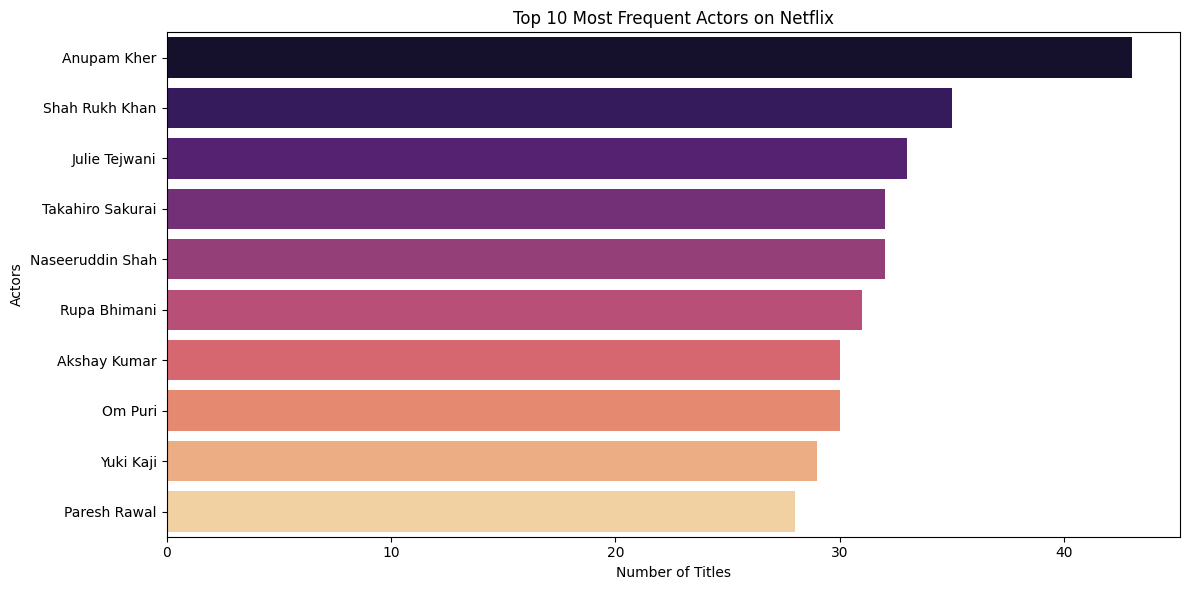

In [18]:
#cleaning null values in cast
ds_copy_3 = ds.copy()
ds_copy_3.dropna(subset=['cast'], inplace=True)
#separting list of casts into individual actors
ds_copy_3['actor'] = ds_copy_3['cast'].str.split(', ')
ds_copy_3 = ds_copy_3.explode('actor')
#Grouping by actors and finding total count of movies and shows by each directors
actors = ds_copy_3.groupby(['actor']).size().reset_index(name='count')
# Sort directors in descending value
top_actors = actors.sort_values(by='count', ascending=False).head(10)

# Plot
plt.figure(figsize=(12, 6))
sns.barplot(x='count', y='actor', data=top_actors, palette='magma')
plt.title('Top 10 Most Frequent Actors on Netflix')
plt.xlabel('Number of Titles')
plt.ylabel('Actors')
plt.tight_layout()
plt.show()